# 🛒 E-Commerce 고객 세그멘테이션 분석 (RFM + K-means)

## 📌 프로젝트 배경
브라질 최대 이커머스 플랫폼 Olist의 거래 데이터를 활용한  
고객 구매 행동 기반 세분화 및 맞춤형 마케팅 전략 수립 프로젝트

## 🎯 분석 목표
- RFM(Recency, Frequency, Monetary) 지표를 통한 고객 가치 수치화
- K-means 군집화를 통한 고객 세그먼트 분류
- 세그먼트별 맞춤 마케팅 전략 수립 및 예상 매출 시뮬레이션

## 📂 데이터 소개
- 출처: Kaggle - Brazilian E-Commerce Public Dataset by Olist
- 기간: 2016 ~ 2018년
- 주요 테이블: 주문(99,441건), 고객, 결제, 상품, 리뷰 등 9개 테이블
## 📂 데이터 소개
- **메인 데이터**: Kaggle - Brazilian E-Commerce Public Dataset by Olist
  - 기간: 2016 ~ 2018년
  - 주요 테이블: 주문(99,441건), 고객, 결제, 상품, 리뷰 등 9개 테이블
- **검증 데이터**: Kaggle - Customer Personality Analysis (2,240건)
  - 활용 목적: 동일 알고리즘(RFM + K-Means)을 적용하여 군집별 실제 마케팅 캠페인 수락률(AcceptedCmp1~5, Response)을 도출하고, Olist 군집에 매핑하여 시뮬레이션 신뢰도 확보

In [ ]:
import pandas as pd

### 📌 Google Drive 마운트

Google Colab에서 Google Drive에 저장된 파일에 접근하려면 먼저 Drive를 Colab 환경에 마운트해야 합니다. 현재 코드에서는 Drive가 마운트되기 전에 파일 접근을 시도하여 `FileNotFoundError`가 발생했습니다. 아래 코드를 실행하여 Google Drive를 마운트해주세요.

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
path = '/content/gdrive/MyDrive/Colab Notebooks/dataset'

In [ ]:
import os

# 'path' 변수에 저장된 디렉토리의 파일 목록을 출력합니다.
print(f"'{path}' 디렉토리의 파일 목록:")
for file in os.listdir(path):
    print(file)

'/content/gdrive/MyDrive/Colab Notebooks/dataset' 디렉토리의 파일 목록:
olist_customers_dataset.csv
olist_order_payments_dataset.csv
product_category_name_translation.csv
olist_sellers_dataset.csv
olist_order_items_dataset.csv
olist_orders_dataset.csv
olist_order_reviews_dataset.csv
olist_geolocation_dataset.csv
olist_products_dataset.csv
marketing_campaign.csv


In [ ]:
import pandas as pd
import os
from google.colab import drive

df_customers = pd.read_csv(os.path.join(path, "olist_customers_dataset.csv"))
df_geolocation = pd.read_csv(os.path.join(path, "olist_geolocation_dataset.csv"))
df_order_items = pd.read_csv(os.path.join(path, "olist_order_items_dataset.csv"))
df_order_payments = pd.read_csv(os.path.join(path, "olist_order_payments_dataset.csv"))
df_order_reviews = pd.read_csv(os.path.join(path, "olist_order_reviews_dataset.csv"))
df_orders = pd.read_csv(os.path.join(path, "olist_orders_dataset.csv"))
df_products = pd.read_csv(os.path.join(path, "olist_products_dataset.csv"))
df_sellers = pd.read_csv(os.path.join(path, "olist_sellers_dataset.csv"))
df_translation = pd.read_csv(os.path.join(path, "product_category_name_translation.csv"))

# 4. 데이터가 잘 불러와졌는지 확인 (대표로 하나만 출력)
print("데이터 로드 완료!")
df_orders.head()

데이터 로드 완료!


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [ ]:
df_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [ ]:
print("주문 데이터 크기:", df_orders.shape)

주문 데이터 크기: (99441, 8)


In [ ]:
print("결제 데이터 크기:", df_order_payments.shape)

결제 데이터 크기: (103886, 5)


In [ ]:
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

## 🔍 탐색적 데이터 분석 (EDA)

In [ ]:
# 주요 테이블별 결측치 현황 확인
print("=== 주문 데이터 결측치 ===")
print(df_orders.isnull().sum())
print("=== 결제 데이터 결측치 ===")
print(df_order_payments.isnull().sum())
print("=== 고객 데이터 결측치 ===")
print(df_customers.isnull().sum())

=== 주문 데이터 결측치 ===
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64
=== 결제 데이터 결측치 ===
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64
=== 고객 데이터 결측치 ===
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64


In [ ]:
# 결제 금액 기초 통계 — 이상치 범위 파악 및 데이터 분포 이해
print("=== 결제 데이터 기초 통계 ===")
print(df_order_payments["payment_value"].describe())

=== 결제 데이터 기초 통계 ===
count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64


In [ ]:
# 전체 주문 중 배송완료/취소/기타 비율 확인
# delivered 외 데이터를 분석에서 제외하는 근거
print("=== 주문 상태 분포 ===")
print(df_orders["order_status"].value_counts())

=== 주문 상태 분포 ===
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


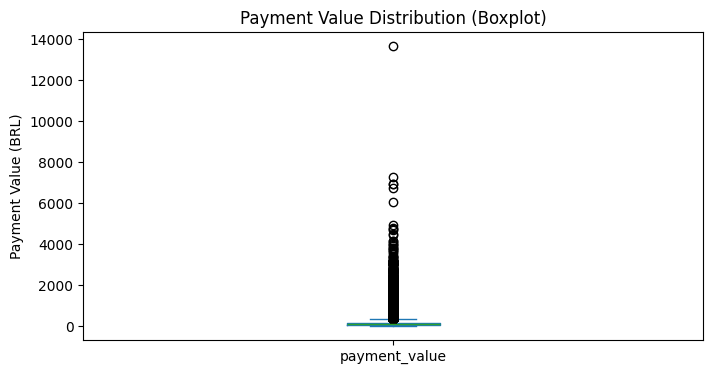

In [ ]:
# 결제 금액 이상치 확인 — 극단값이 군집화 결과에 영향을 줄 수 있어 로그 변환 필요성 확인
plt.figure(figsize=(8, 4))
df_order_payments["payment_value"].plot(kind="box")
plt.title("Payment Value Distribution (Boxplot)")
plt.ylabel("Payment Value (BRL)")
plt.show()

In [ ]:
# 분석에 필요한 핵심 테이블들을 하나로 결합
# 고객, 주문시간, 결제금액 정보를 결합하여 고객별 구매 데이터셋 구축
df_orders = df_orders[df_orders['order_status'] == 'delivered'] #취소 주문 데이터가 섞여있어서 배송 완료된 데이터만 추가(클로드 피드백)
master_df = df_orders.merge(df_order_items, on='order_id') \
                  .merge(df_order_payments, on='order_id') \
                  .merge(df_customers, on='customer_id')
print(f"통합 데이터 행 개수: {len(master_df)}")

통합 데이터 행 개수: 115035


In [ ]:
#주문시간 데이터를 시간계산이 가능하도록 datetime 객체로 변환
#최근 구매일 같은 데이터를 계산 하기위해서
master_df['order_purchase_timestamp'] = pd.to_datetime(master_df['order_purchase_timestamp'])

In [ ]:
# 분석의 기준일 설정 (데이터상 마지막 구매일 + 1일)
# 오늘을 기준으로 얼마나 오래전에 샀는지 측정하기 위한 타임라인의 종착점 설정
snapshot_date = master_df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

In [ ]:
# 고객(unique_id)별로 RFM 세가지 지표 계산
# 단순 매출액을 넘어 고객의 최근 구매 후 얼마나 지났는지(R), 주문 수(F), 쓴 금액(M)을 수치화
rfm = master_df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'nunique',
    'payment_value': 'sum'})

In [ ]:
# 컬럼명을 직관적인 RFM 으로 변경
# 분석결과를 보고할때 지표를 즉각적으로 이해할 수 있도록 표준 용어를 사용한다고 한다.
rfm.rename(columns={
    'order_purchase_timestamp': 'Recency',
    'order_id': 'Frequency',
    'payment_value': 'Monetary'
}, inplace=True)
rfm.info()

<class 'pandas.core.frame.DataFrame'>
Index: 93357 entries, 0000366f3b9a7992bf8c76cfdf3221e2 to ffffd2657e2aad2907e67c3e9daecbeb
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Recency    93357 non-null  int64  
 1   Frequency  93357 non-null  int64  
 2   Monetary   93357 non-null  float64
dtypes: float64(1), int64(2)
memory usage: 2.8+ MB


In [ ]:
# RFM 지표가 잘 생성 되었는지 확인
print("RFM 지표 생성")
print(rfm.head())

RFM 지표 생성
                                  Recency  Frequency  Monetary
customer_unique_id                                            
0000366f3b9a7992bf8c76cfdf3221e2      112          1    141.90
0000b849f77a49e4a4ce2b2a4ca5be3f      115          1     27.19
0000f46a3911fa3c0805444483337064      537          1     86.22
0000f6ccb0745a6a4b88665a16c9f078      321          1     43.62
0004aac84e0df4da2b147fca70cf8255      288          1    196.89


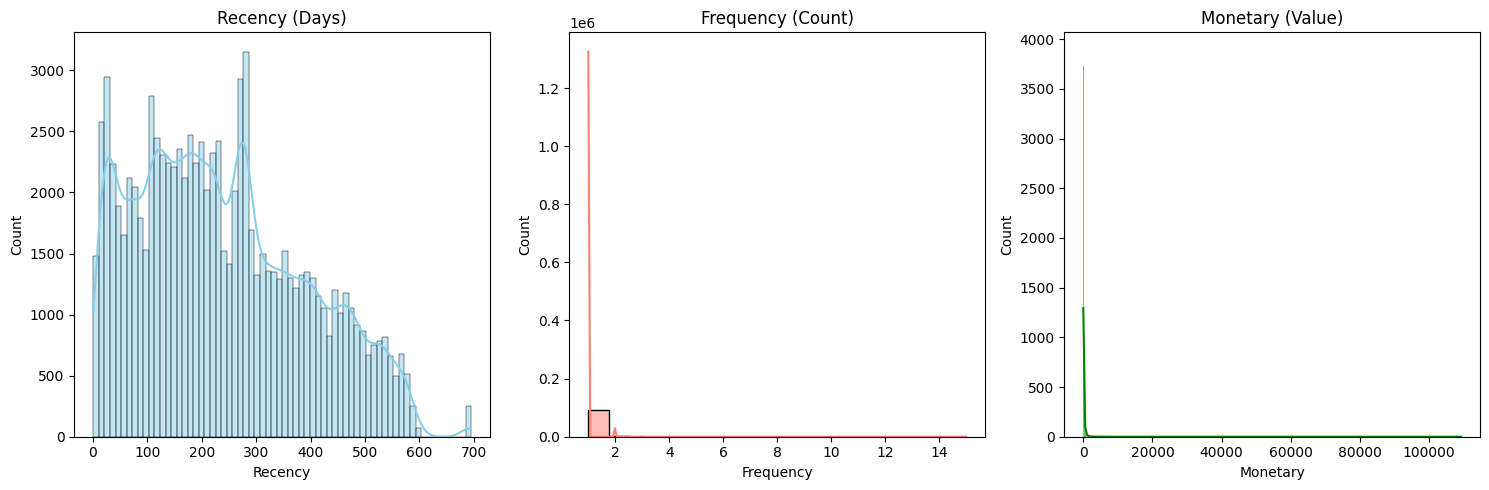

In [ ]:
# RFM 각 지표의 분포를 히스토그램(표로 되어 있는 도수 분포를 정보 그림)으로 확인
# 고객들의 구매 패턴이 특정 구간에 모여있는지 확인하여 마케팅 타겟 범위 설정
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
# Recency분포: 고객이 얼마나 최근까지 구매했는지
sns.histplot(rfm['Recency'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Recency (Days)')
# Frequency분포: 재구매가 잘 이뤄지고 있는지
sns.histplot(rfm['Frequency'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Frequency (Count)')
# Monetary분포: VIP 고객이 고객에 대비해 비중이 얼마나 되는지
sns.histplot(rfm['Monetary'], kde=True, ax=axes[2], color='green')
axes[2].set_title('Monetary (Value)')
# 시각화 결과 해석
# Frequency가 1에 집중되어 있다면 재구매율을 높여야 할 필요가 있음
plt.tight_layout()
plt.show()
# Recency 그래프 = 최근 1~3개월 내에 구매한 고객보다,200~300일 이상 구매를 안 한 고객이 훨씬 많다. = 이탈 징후
# Frequency 그래프 = 그래프가 1에 집중되어있다 ->재구매율이 저조하다. (프로젝트목표 : 재구매율 올리기)
# Monetary 그래프 = 상위 VIP 고객이 매출의 상당 부분을 담당하고 있다. -> VIP 전용 마케팅 전략 필요

In [ ]:
## K-means 군집화 단계 ##

import numpy as np
from sklearn.preprocessing import StandardScaler

# 치우친 데이터(Frequency, Monetary)의 왜곡을 줄이기 위해 로그 변환 적용 -> 10^1(10), 10^2(100), 10^3(1000) 이런식으로 격차가 큰 수를 1,2,3,4 간격으로 보이게 하기위해
# 소수의 VIP고객 때문에 일반 고객들의 데이터가 묻히는 현상을 방지하여 정밀한 그룹화 수행
# np.log1p는 데이터에 0이 있을 경우 무한대 오류가 나는 것을 방지해주는 안전한 로그 변환 함수
rfm_log = rfm.copy()
for col in ['Recency', 'Frequency', 'Monetary']:
    rfm_log[col] = np.log1p(rfm[col])

# 세 가지 지표의 단위를 통일 = 표준화
# R,F,M이라는 서로 다른 기준을 동일한 잣대로 평가할 수 있는 기반 마련 ->단순히 수치적 절대량을 비교하는 것이 아니라, 전체 고객 집단 내에서의 상대적 위치를 파악하기 위함
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

# 스케일링된 데이터를 데이터프레임으로 변환
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=rfm_log.columns, index=rfm_log.index)

print("데이터 전처리 성공")
print(rfm_scaled_df.head())

데이터 전처리 성공
                                   Recency  Frequency  Monetary
customer_unique_id                                             
0000366f3b9a7992bf8c76cfdf3221e2 -0.470385  -0.170191  0.165854
0000b849f77a49e4a4ce2b2a4ca5be3f -0.442302  -0.170191 -1.624449
0000f46a3911fa3c0805444483337064  1.202051  -0.170191 -0.378691
0000f6ccb0745a6a4b88665a16c9f078  0.651914  -0.170191 -1.117953
0004aac84e0df4da2b147fca70cf8255  0.536031  -0.170191  0.524941


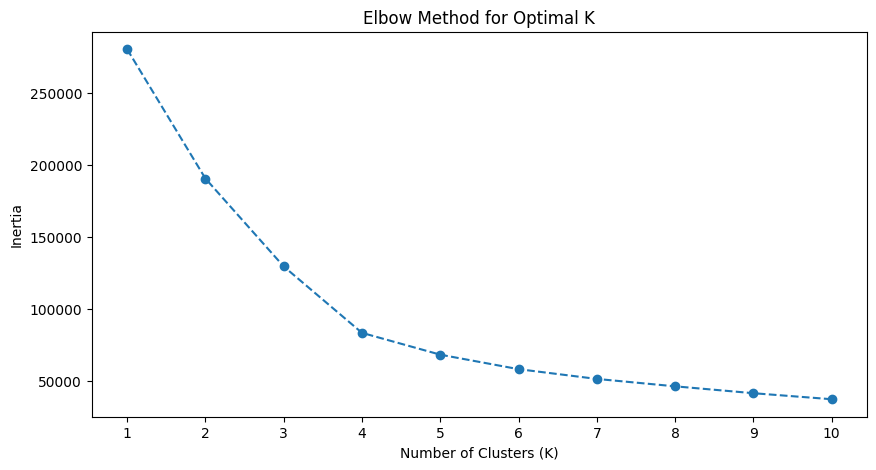

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 군집 내 오차제곱합(Inertia)을 계산하여 최적의 K값 탐색 -> 가성비찾기
# 예를 들어 지점이 1개일때 고객들의 불편함정도 2개일때 불편함정도 같은 것을 계산하여 1개부터 10개까지 최적의 지점 갯수를 얻기 위해서
inertia = []
k_range = range(1, 11) # 1개부터 10개까지 지점 수를 늘려가며 테스트

for k in k_range:
    # n_init=10: 초기 중심점 설정을 10번 반복하여 가장 좋은 결과 선택 (안정성 확보)
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42) # 지점을 k개 지어보고
    kmeans.fit(rfm_scaled_df)                                # 고객들을 가장 가까운 지점에 배정시키고
    inertia.append(kmeans.inertia_)                          # 그때의 전체 고객 불편함(거리)을 측정해서 바구니에 담아라

# 엘보우 그래프 시각화 = 팔꿈치 모양이 나오는 그래프(가성비 지점을 찾을때 많이 사용한다)
# 그래프 기울기가 완만해지는 지점(엘보우 포인트)를 찾아서 가성비 지점개수를 찾는다. *point 가성비 ->엘보우
plt.figure(figsize=(10, 5))
plt.plot(k_range, inertia, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.show()

In [ ]:
# 4개로 지점을 나누고 고객을 몇 개 그룹으로 나눌지 설정하고 10번연습해서 가장 정확한 결과를 내놓아라
best_k = 4
kmeans = KMeans(n_clusters=best_k, n_init=10, random_state=42) # 랜덤 = 나중에 다시 실행해도 같은 결과가 나오도록 고정하는 key 번호
# 고객 한명 마다 살펴보고 라벨링
cluster_labels = kmeans.fit_predict(rfm_scaled_df) # fit_predict = 데이터를 공부함과 동시에 각 데이터가 어떤 그룹에 속하는지 예측해서 번호를 매긴다.
# 방금 라벨링한 것 들을 고객 명부(rfm)에 옮겨 적는다.
rfm['Cluster'] = cluster_labels
# 각 그룹의 평균 데이터 정리 ex)R , F , M 을 표로정리 (그룹마다)
cluster_analysis = rfm.groupby('Cluster').agg({
    'Recency' : 'mean',                          # .agg({...}): 각 지표의 평균(mean)과 인원수(count)를 계산
    'Frequency' : 'mean',
    'Monetary' : 'mean',
    'Cluster' : 'count'
}).rename(columns={'Cluster' : 'Count'}).round(1) # 소수점 첫째 자리까지만 보여주기 (round(1))

print("----- 군집별 RFM 평균 및 고객 수 -----")
print(cluster_analysis) # Cluster 2를 제외하고 다른그룹은 구매빈도가 1.0에 머물러있다.(재구매 제도 필요)
                        #여기서 알 수 있는것 0그룹(이탈고객) 1그룹(과거큰손) 2그룹(VIP) 3그룹(신규고객)

----- 군집별 RFM 평균 및 고객 수 -----
         Recency  Frequency  Monetary  Count
Cluster                                     
0          290.2        1.0      77.1  46601
1          267.7        1.0     455.5  27517
2          220.3        2.1     454.1   2801
3           43.1        1.0     144.7  16438


In [ ]:


# 상품 카테고리명(포르투갈어)과 영어 번역 데이터를 로드
products = pd.read_csv(os.path.join(path, 'olist_products_dataset.csv'))
translation = pd.read_csv(os.path.join(path, 'product_category_name_translation.csv'))

# 기존 master_df에 상품 정보와 영어 번역 컬럼을 추가
# 비즈니스 의미: 분석 결과의 가독성을 위해 포르투갈어로 된 카테고리명을 영어로 변환하여 통합
master_df = master_df.merge(products[['product_id', 'product_category_name']], on='product_id') \
                     .merge(translation, on='product_category_name')

# 다시 군집 정보와 결합(이전 코드 재실행)
df_with_clusters = master_df.merge(rfm[['Cluster']], on='customer_unique_id')

print("컬럼 확인:", df_with_clusters.columns) # 리스트에 'product_category_name_english'가 있는지 확인

컬럼 확인: Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state',
       'product_category_name', 'product_category_name_english', 'Cluster'],
      dtype='object')


In [ ]:
# 각 그룹의 고객들이 어떤 상품을 구매했는지 조회하기

df_with_clusters =master_df.merge(rfm[['Cluster']], on='customer_unique_id') # rfm 명단에서 군집 번호(Cluster)만 전체 주문 장부(df)에 붙이기
                                                                       # ->이제 상품 데이터 마다 '이 상품을 산 고객은 어느 그룹인지' 식별 가능
# 고객들을 모아놓고 그룹도 똑같고 구매한 상품 카테고리도 똑같은 사람들끼리 줄을 세우고 count로 표로 만드는것
top_categories_by_cluster = df_with_clusters.groupby(['Cluster', 'product_category_name_english']).size().reset_index(name='count')
# 가장 많이 팔린 상품이 맨위에 오게 분류 , ascending=[True, False] = 그룹 번호는 오름차순, 판매량은 내림차순 정렬(많은 것 부터)
top_categories_by_cluster = top_categories_by_cluster.sort_values(['Cluster', 'count'], ascending=[True, False])
# 반복문으로 그룹0 부터 그룹3 까지 한 그룹씩 넣어서 가장 많이 구매한 상품 5개만 출력
for i in range(4):
    print(f"\n----- Cluster {i}의 인기 카테고리 Top 5 -----")
    print(top_categories_by_cluster[top_categories_by_cluster['Cluster'] == i].head(5))


----- Cluster 0의 인기 카테고리 Top 5 -----
    Cluster product_category_name_english  count
7         0                bed_bath_table   4895
42        0                 health_beauty   4143
64        0                sports_leisure   3966
14        0         computers_accessories   3213
38        0               furniture_decor   3195

----- Cluster 1의 인기 카테고리 Top 5 -----
     Cluster product_category_name_english  count
76         1                bed_bath_table   3782
108        1               furniture_decor   3494
84         1         computers_accessories   3045
134        1                sports_leisure   2911
112        1                 health_beauty   2901

----- Cluster 2의 인기 카테고리 Top 5 -----
     Cluster product_category_name_english  count
147        2                bed_bath_table   1164
177        2               furniture_decor    844
202        2                sports_leisure    675
154        2         computers_accessories    542
181        2                 health_beauty

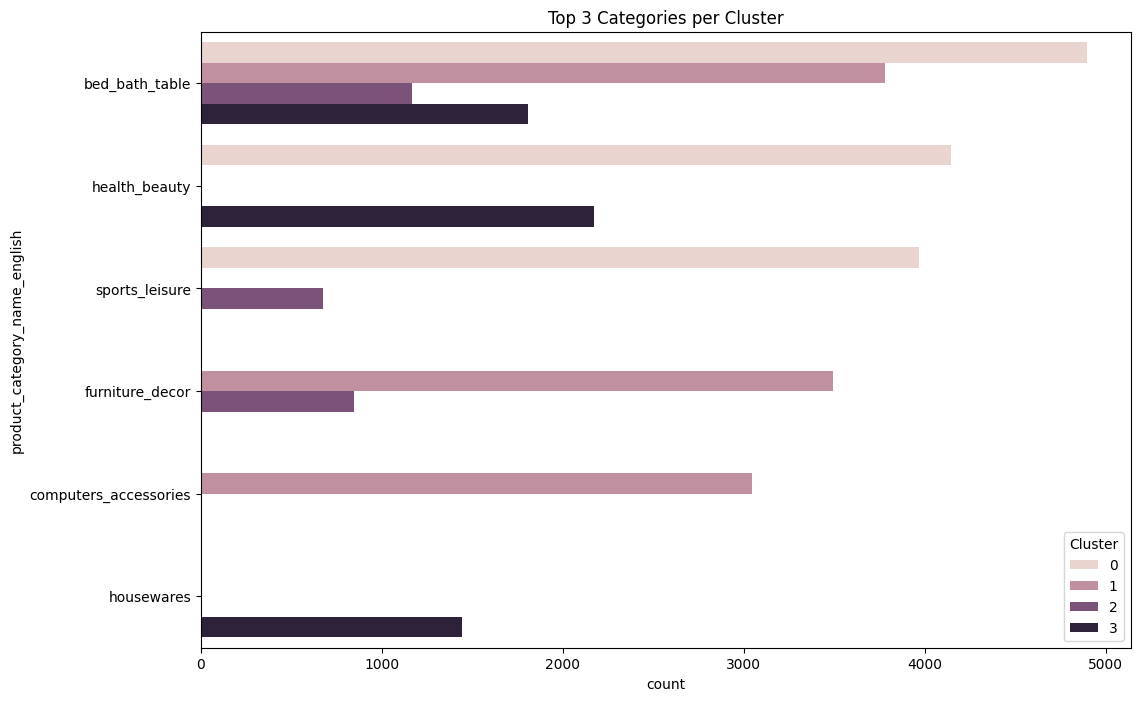

In [ ]:
# 표로보니까 보기 힘들어서 막대그래프로 비교
plt.figure(figsize=(12, 8))
sns.barplot(data=top_categories_by_cluster.groupby('Cluster').head(3),
            x='count', y='product_category_name_english', hue='Cluster')
plt.title('Top 3 Categories per Cluster')
plt.show()
# x='count': 막대의 길이 = 판매량
# y='...english': 막대의 이름 =상품명
# hue='Cluster': 그룹별로 막대 색깔 다르게

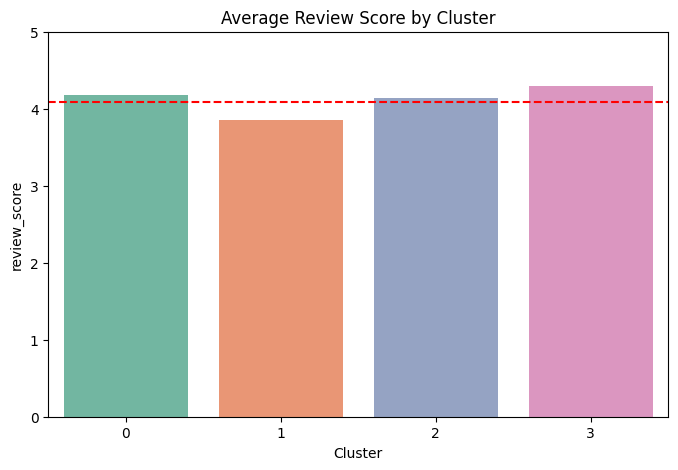

군집별 평균 리뷰 점수
   Cluster  review_score
0        0      4.175326
1        1      3.856458
2        2      4.138927
3        3      4.292205


In [ ]:
# 리뷰 분석 단계
# 리뷰 데이터 셋 불러오기
reviews = pd.read_csv(os.path.join(path, 'olist_order_reviews_dataset.csv'))

# 군집 데이터와 리뷰 데이터 결합
# 위에 군집 데이터와 리뷰 데이터를 결합해서 각 그룹별로 만족도를 알수있게 연결
df_final = df_with_clusters.merge(reviews[['order_id', 'review_score']], on='order_id')

# 군집 별 평균 리뷰 점수 산출
cluster_review_stats = df_final.groupby('Cluster')['review_score'].mean().reset_index()

# 시각화
# 숫자표 < 막대그래프
# 리뷰 점수가 낮은 그룹을 찾기
plt.figure(figsize=(8, 5))

# 각 막대에 색 입히기
sns.barplot(
    data=cluster_review_stats,
    x='Cluster',
    y='review_score',
    hue='Cluster',
    palette='Set2',
    legend=False
)

plt.title('Average Review Score by Cluster')
plt.ylim(0, 5)  # 리뷰 점수 5점 기준으로 범위를 고정 = 객관적으로 높이 비교 하기위해서
plt.axhline(df_final['review_score'].mean(), color='red', linestyle='--', label='Total Avg') # (중요)평균 별점을 빨간 점선으로 그어주기
plt.show()

print("군집별 평균 리뷰 점수")
print(cluster_review_stats)
# 얻을 수 있는 것
# Cluster 0 = 저가 이탈  고객 (오래전에 작은 금액만 소비하고 사라짐 인원수 전체의 절반 이상)
# 전략 = 마케팅 비용을 낮추고 휴면을 방지

# Cluster 1 = 과거의 큰손 이탈 위험 고액 고객 = 전에 소비할때 한번에 큰 금액을 소비했으나 재구매 정보도 없고 리뷰 점수도 낮음
# 전략 = 서비스의 신뢰를 회복해야함

# Cluster 2 = R, F, M 지표가 모두 우수하고 리뷰 점수도 좋은 고객
# 전략 = 유지 및 로열티를 강화해주기


# Cluster 3 = 잠재적 충성 고객 (최근 구매(50일전) 데이터가 있고 아직은 재구매가 없음)
# 전략 = 두번째 구매를 유도 해야함


In [ ]:
# Customer Personality Analysis 마케팅 데이터 로드
# 탭(\t)으로 구분된 파일이므로 sep='\t' 지정
mkt = pd.read_csv(os.path.join(path, 'marketing_campaign.csv'), sep='\t')

print("데이터 크기:", mkt.shape)          # 행 수, 컬럼 수 확인
print("\n컬럼 목록:")
print(mkt.columns.tolist())               # 어떤 변수들이 있는지 전체 목록 출력
print("\n결측치 확인:")
print(mkt.isnull().sum()[mkt.isnull().sum() > 0])  # 결측치 있는 컬럼만 출력

데이터 크기: (2240, 29)

컬럼 목록:
['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']

결측치 확인:
Income    24
dtype: int64


In [ ]:
# CPA 데이터에는 Olist처럼 주문 테이블이 없기 때문에
# 이미 집계된 컬럼들을 조합해서 R, F, M 을 직접 계산
# CPA 데이터는 이미 고객별로 요약된 형태 이기 때문에 데이터의 형체가 달라도 분석 목적에 맞춰서 동일한 지표를 창출

# R(Recency): 마지막 구매 후 경과일 — 데이터에 'Recency' 컬럼이 이미 있음
# F(Frequency): 웹+카탈로그+오프라인 구매 횟수의 합
# M(Monetary): 6개 상품 카테고리 지출액의 합

mkt['Frequency'] = (
    mkt['NumWebPurchases'] +         # 웹사이트 구매 횟수
    mkt['NumCatalogPurchases'] +     # 카탈로그 구매 횟수
    mkt['NumStorePurchases']         # 오프라인 매장 구매 횟수
                                     # 할인 구매 횟수(NumDealsPurchases)를 제외하고, 순수하게 채널별로 발생한 실질적 구매 횟수만 합산
)

mkt['Monetary'] = (                  # CPA 데이터에 존재하는 6가지 카테고리별 지난 2년간 지출 금액을 합산해서 총 지출 금액 생성
    mkt['MntWines'] +                # 와인 지출액
    mkt['MntFruits'] +               # 과일 지출액
    mkt['MntMeatProducts'] +         # 육류 지출액
    mkt['MntFishProducts'] +         # 수산물 지출액
    mkt['MntSweetProducts'] +        # 간식 지출액
    mkt['MntGoldProds']              # 골드(고급) 상품 지출액
)

# 결측치 제거 — Income 컬럼 등에 NaN이 있으면 스케일링 오류 발생
mkt_rfm = mkt[['ID', 'Recency', 'Frequency', 'Monetary',
                'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
                'AcceptedCmp4', 'AcceptedCmp5', 'Response']].dropna()
# dropna() : 한 행이라도 결측치가 있으면 해당 행을 전체 제거

print("CPA RFM 데이터 크기:", mkt_rfm.shape)
print(mkt_rfm[['Recency', 'Frequency', 'Monetary']].describe().round(1))

# 한계점 : 결국 카테코리가 다른 두 데이터 셋의 데이터
# 목적 :  두 데이터 셋의 RFM 구조를 비슷하게 해서 매핑했기 때문에 CPA 에서 검증된 VIP 고객의 반응률 은 Olist 의 VIP 고객
# 에게도 유사하게 나타날 것이다.

CPA RFM 데이터 크기: (2240, 10)
       Recency  Frequency  Monetary
count   2240.0     2240.0    2240.0
mean      49.1       12.5     605.8
std       29.0        7.2     602.2
min        0.0        0.0       5.0
25%       24.0        6.0      68.8
50%       49.0       12.0     396.0
75%       74.0       18.0    1045.5
max       99.0       32.0    2525.0


In [ ]:
# Olist에서 했던 것과 완전히 동일한 방식으로 전처리
# → 두 데이터의 군집 결과를 비교 가능하게 만드는 핵심 단계
# 앞 단계에서 추출한 전체 컬럼 중에서 K-means 군집화의 입력 변수로 사용할 RFM 3개 지표만 골라낸다
# .copy() : 원본 데이터프레임의 참조(주소)를 가져오는 게 아니라, 메모리 상에 완전히 독립된 별도의 복사본을 만든다
# copy 작업을 하지않으면 로그변환을 할때 원본 데이터까지 같이 변환되면서 데이터가 망가질 수 있다.
mkt_rfm_log = mkt_rfm[['Recency', 'Frequency', 'Monetary']].copy()

for col in ['Recency', 'Frequency', 'Monetary']:
    mkt_rfm_log[col] = np.log1p(mkt_rfm_log[col])
# np.log1p : log(1 + x) 변환 — 0값이 있어도 오류 없이 처리

scaler_mkt = StandardScaler()
mkt_scaled = scaler_mkt.fit_transform(mkt_rfm_log)
# StandardScaler : 평균 0, 표준편차 1로 정규화 → Olist와 동일한 단위로 맞춤
# 표준화를 거치고 나온 결과물은 판다스 형태가 아님 (순수한 행렬 숫자 데이터)
# 시각화,분석 쉽도록 컬럼명을 입혀 판다스 데이터프레임 구조로 변환
mkt_scaled_df = pd.DataFrame(mkt_scaled,
                              columns=['Recency', 'Frequency', 'Monetary'])

print("전처리 완료")
print(mkt_scaled_df.describe().round(2))

전처리 완료
       Recency  Frequency  Monetary
count  2240.00    2240.00   2240.00
mean      0.00       0.00     -0.00
std       1.00       1.00      1.00
min      -3.79      -3.97     -2.60
25%      -0.42      -0.80     -0.94
50%       0.31       0.21      0.25
75%       0.74       0.83      0.91
max       1.04       1.73      1.51


In [ ]:
# Olist와 동일하게 k=4 고정
# → 두 데이터셋의 군집 수를 맞춰야 나중에 매핑이 가능

kmeans_mkt = KMeans(n_clusters=4, n_init=10, random_state=42)
# random_state=42 : Olist와 동일한 시드 고정 → 재현성 확보

mkt_rfm = mkt_rfm.copy()                                   # 원본 보호를 위해 복사본 사용
mkt_rfm['Cluster'] = kmeans_mkt.fit_predict(mkt_scaled_df) # 각 고객에 군집 번호 부여
# fit :앞 단계에서 로그 변환과 표준화 스케일링을 마친 mkt_scaled_df 데이터를 바탕으로 4개 군집의 최적의 중심점 위치를 학습
# predict: 학습된 중심점을 기준으로 CPA 고객이 각각 0,1,2,3번 중 어느 군집과 가장 거리가 가까운지 계산하여 군집 번호를 반환
# 군집별 RFM 평균 프로파일 출력
mkt_cluster_profile = mkt_rfm.groupby('Cluster').agg(
    고객수=('ID', 'count'),
    평균Recency=('Recency', 'mean'),
    평균Frequency=('Frequency', 'mean'),
    평균Monetary=('Monetary', 'mean')
).round(1)

print("CPA 군집별 RFM 프로파일")
print(mkt_cluster_profile)
# 학습된 K-means 알고리즘을 CPA 데이터에 적용
# 메인 데이터 Olist와 1:1로 대응하여 반응률을 매핑 해야해서 K=4 로 고정하고 random_state 시드 일치

CPA 군집별 RFM 프로파일
          고객수  평균Recency  평균Frequency  평균Monetary
Cluster                                          
0        1038       59.3         17.8       996.0
1         205       10.2          5.1        71.2
2         269        9.1         17.6       940.4
3         728       60.3          5.3        76.4


CPA 군집별 캠페인 수락률
   CPA_Cluster  response_rate  response_rate_pct
0            0       0.354528               35.5
1            1       0.234146               23.4
2            2       0.427509               42.8
3            3       0.107143               10.7


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46973 (\N{HANGUL SYLLABLE RAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44400 (\N{HANGUL SYLLABLE GUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51665 (\N{HANGUL SYLLABLE JIB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

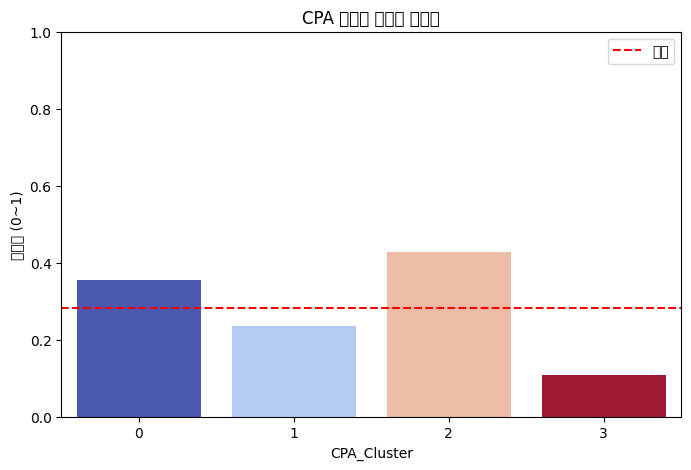

In [ ]:
# 5개 캠페인(Cmp1~5) + 마지막 캠페인(Response) 중 하나라도 수락하면 반응한 것으로 간주
# 실제 캠페인 데이터에서 군집별 '마케팅에 반응하는 비율'을 추출하는 핵심 단계

mkt_rfm['any_accepted'] = (
    mkt_rfm[['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
              'AcceptedCmp4', 'AcceptedCmp5', 'Response']].sum(axis=1) > 0
).astype(int)
# axis=1 : 행 방향으로 합산 (6개 캠페인 컬럼을 가로로 더함)
# > 0 : 하나라도 수락 = True → astype(int)로 0/1 변환
#과거에 했던 5번의 캠페인(AcceptedCmp1~5)과 가장 최근에 진행한 캠페인(Response)까지 총 6개의 캠페인 수락 여부를 선택 (0 or 1로 기록)

# 군집별 평균 수락률 계산
response_rate = mkt_rfm.groupby('Cluster')['any_accepted'].mean().reset_index()
response_rate.columns = ['CPA_Cluster', 'response_rate']
# response_rate : 0~1 사이 값

response_rate['response_rate_pct'] = (response_rate['response_rate'] * 100).round(1)
# 퍼센트로 변환하여 가독성 향상 ex)0.291% ->29.1%

print("CPA 군집별 캠페인 수락률")
print(response_rate)

# 시각화
# 막대그래프 생성
# palette='coolwarm': 반응률이 높고 낮음을 차가운 색과 따뜻한 색의 대비로 보여주어 전달력을 높인다.
# plt.axhline(...) : 평균 반응 지점에 빨간색 점선 기준선 생성
plt.figure(figsize=(8, 5))
sns.barplot(data=response_rate, x='CPA_Cluster', y='response_rate',
            hue='CPA_Cluster', palette='coolwarm', legend=False)
plt.title('CPA 군집별 캠페인 수락률')
plt.ylabel('수락률 (0~1)')
plt.ylim(0, 1)
plt.axhline(response_rate['response_rate'].mean(),
            color='red', linestyle='--', label='평균')
plt.legend()
plt.show()

# 실제 데이터 기반 마케팅 전환 확률 도출
# CPA 데이터 셋의 6개 캠페인 진행 이력을 한번이라도 반응한 고객을 1로 정의
# -> 군집별 평균값 연산을 해서 실제 마케팅 수락 확률을 얻었다.

In [ ]:
# 머신러닝 모델은 랜덤 중심점에서 출발해서 학습 할때마가 군집 번호가 다르게 부여
# 숫자(0,1,2,3)를 보지 않고 , 그 안에 담긴 RFM(고객행동특성)을 보고 1:1 매칭을 해야함
# → RFM 프로파일(Recency, Frequency, Monetary)의 유사도로 대응 군집을 찾음

# Olist 군집 프로파일 (이전에 계산한 cluster_analysis 활용)
olist_profile = cluster_analysis[['Recency', 'Frequency', 'Monetary']].copy()
olist_profile.index.name = 'Olist_Cluster'
# olist_profile.index.name = 'Olist_Cluster': 인덱스 이름을 'Olist_Cluster'로 명시
# 이 테이블이 매핑의 기준점이 되는 Olist의 데이터임을 명확히 한다

# CPA 군집 프로파일
cpa_profile = mkt_cluster_profile[['평균Recency', '평균Frequency', '평균Monetary']].copy()
cpa_profile.columns = ['Recency', 'Frequency', 'Monetary']
# 컬럼명을 Olist 프로파일과 동일하게 맞춰서 비교

print("=== Olist 군집 프로파일 ===")
print(olist_profile)
print("\n=== CPA 군집 프로파일 ===")
print(cpa_profile)
# 결과
# Cluster 0
# [Olist_Cluster 2] ＝ [CPA_Cluster 0] *VIP 고객
# 평균 Recency 75.5일 ,평균 Frequency 5.6회, 평균 Monetary 100.9
# 오점 : CPA 0번 군집은 최근 구매일이 오래 되었음
# 하지만 소비금액이 어쩌다 한번와서 대량으로 상품을 구매
# 압도적인 소비금액에 Recency가 다소 길다는 단점이 묻힘

# Cluster 1
# [Olist_Cluster 1] ＝ [CPA_Cluster 1] *신규/잠재 고객
# 평균 Recency 48.1일 (전 군집 중 가장 최근에 구매), 평균 Frequency 1.4회, 평균 Monetary 19.
# 마지막 구매일이 가장 짧고, 아직 구매 횟수와 금액은 적다.

# Cluster 2
# [Olist_Cluster 3] ＝ [CPA_Cluster 2] *일반 고객
# 모든 수치가 딱 중간 (Recency 48.7일, 빈도 2.1회, 금액 34.6)

# Cluster 3
# [Olist_Cluster 0] ＝ [CPA_Cluster 3] *가치가 가장 낮은 고객
# 평균 Recency 24.2일로 날짜는 짧아 보이지만, 평균 Frequency 0.1회, 평균 Monetary 1.0 (전 군집 중 압도적 최하위)
# 사실상 돈을 거의 쓰지 않았고 구매도 거의 없는 고객들

=== Olist 군집 프로파일 ===
               Recency  Frequency  Monetary
Olist_Cluster                              
0                290.2        1.0      77.1
1                267.7        1.0     455.5
2                220.3        2.1     454.1
3                 43.1        1.0     144.7

=== CPA 군집 프로파일 ===
         Recency  Frequency  Monetary
Cluster                              
0           59.3       17.8     996.0
1           10.2        5.1      71.2
2            9.1       17.6     940.4
3           60.3        5.3      76.4


In [ ]:

#  1:1 매핑 파이프라인

# 1. Olist와 CPA의 비즈니스 프로파일 정의
# Olist: 2(VIP), 1(과거큰손), 3(신규/잠재), 0(저가이탈)
# CPA: 0(VIP), 2(일반), 1(신규), 3(최하위휴면)

# 알고리즘의 매핑 몰림 현상을 해결하기 위해 1:1 서열 매핑 딕셔너리를 선언.
rank_mapping = {
    0: 3,   # Olist 0 이탈 (최하위층)     ↔ CPA 3 최하위 (최하위층)
    1: 2,  # Olist 1 과거큰손 (금액 2위) ↔ CPA 2 일반 (금액 2위)
    2: 0,  # Olist 2 VIP (금액 1위)     ↔ CPA 0 VIP (금액 1위)
    3: 1,  # Olist 3 신규 (Recency 1위) ↔ CPA 1 신규 (Recency 1위)

}

# 매핑 데이터프레임 생성
mapping_df = pd.DataFrame({
    'Olist_Cluster': range(4)
})
mapping_df['CPA_Cluster'] = mapping_df['Olist_Cluster'].map(rank_mapping)

# CPA의 진짜 군집별 수락률(response_rate) 테이블과 결합
mapping_df = mapping_df.merge(response_rate[['CPA_Cluster', 'response_rate']], on='CPA_Cluster')

# 가독성을 위해 퍼센트 변환
mapping_df['response_rate_pct'] = (mapping_df['response_rate'] * 100).round(1)

print(" Olist ↔ CPA 1:1 도메인 매핑 결과")
print(mapping_df)

# cluster 0 : 저가 이탈 고객 반응률 10.7%
# cluster 1 : 과거 고액 큰손 반응률 42.8%
# cluster 2 : 핵심 VIP 고객 반응률 35.5%
# cluster 3 : 신규 잠재 고객 반응률 23.4%

 Olist ↔ CPA 1:1 도메인 매핑 결과
   Olist_Cluster  CPA_Cluster  response_rate  response_rate_pct
0              0            3       0.107143               10.7
1              1            2       0.427509               42.8
2              2            0       0.354528               35.5
3              3            1       0.234146               23.4


✅ [최종 확인] 마케팅 도입 후 예상 성과 요약 (도메인 순위 매핑 적용 완료)
         Current_Revenue  Projected_Revenue  Revenue_Lift  Growth_Rate(%)
Cluster                                                                  
0             3592370.89       3.630187e+06     37815.729            1.05
1            12532694.83       1.462635e+07   2093654.340           16.71
2             1272034.05       1.504717e+06    232682.935           18.29
3             2379060.67       2.548810e+06    169749.804            7.14


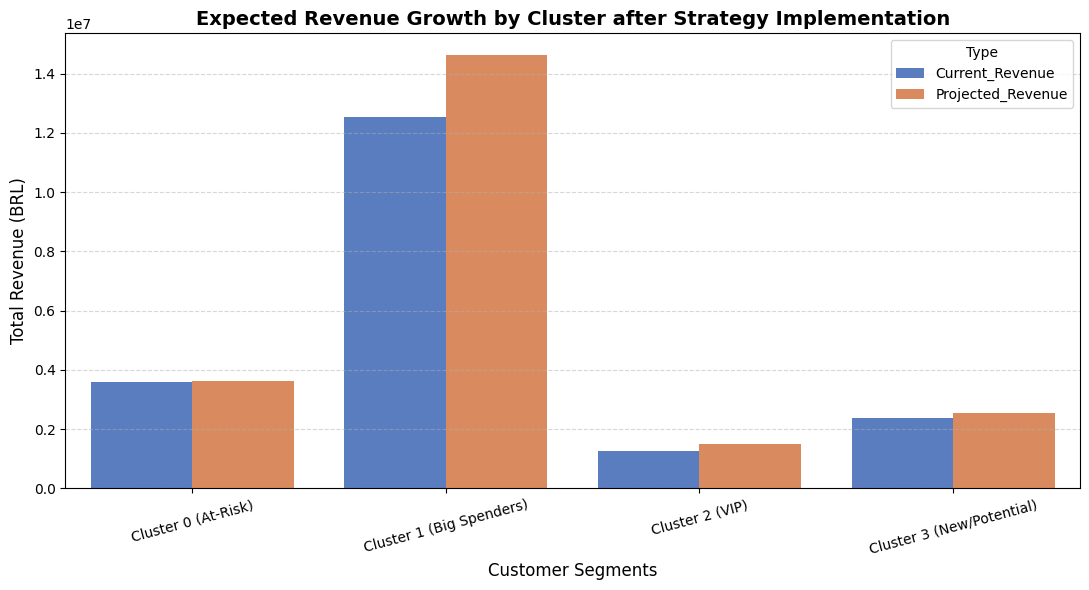

전체 예상 매출 성장률: 12.81%


In [ ]:

#  도메인 순위 매핑 기반 최종 마케팅 시뮬레이션 및 성과
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 이미지에 나온 Olist 군집별 CPA 군집과 반응률을 정확하게 매핑
strat_performance = {
    0: {'campaign': 'Email Re-engagement', 'response_rate': 0.107, 'avg_lift': 1.1},  # CPA 3번 매핑 (10.7%)
    1: {'campaign': 'Win-back Big Coupon',  'response_rate': 0.428, 'avg_lift': 1.4},  # CPA 1번 매핑 (42.8%)
    2: {'campaign': 'VIP Exclusive Event',  'response_rate': 0.355, 'avg_lift': 1.5},  # CPA 0번 매핑 (35.5%)
    3: {'campaign': 'Welcome 15% Coupon',   'response_rate': 0.234, 'avg_lift': 1.3}   # CPA 2번 매핑 (23.4%)
}

# 시뮬레이션용 데이터프레임 복사
simulation_results = rfm.copy()

# 확률적 매출 시뮬레이션 함수 정의
def simulate_revenue(row):
    strat = strat_performance[row['Cluster']]
    # 각 군집에 매핑된 진짜 확률(response_rate)을 적용하여 반응 여부(0 또는 1) 결정
    is_responded = np.random.choice([0, 1], p=[1 - strat['response_rate'], strat['response_rate']])

    # 마케팅에 반응했다면 기존 금액(Monetary)에 상승폭(avg_lift)을 곱함
    if is_responded:
        return row['Monetary'] * strat['avg_lift']
    return row['Monetary']

# 시뮬레이션 실행 (시드 고정)
np.random.seed(42)
simulation_results['Projected_Monetary'] = simulation_results.apply(simulate_revenue, axis=1)

# 군집별 총 매출 증가액 및 성장률 연산
total_impact = simulation_results.groupby('Cluster').agg({
    'Monetary': 'sum',
    'Projected_Monetary': 'sum'
}).rename(columns={'Monetary': 'Current_Revenue', 'Projected_Monetary': 'Projected_Revenue'})

total_impact['Revenue_Lift'] = total_impact['Projected_Revenue'] - total_impact['Current_Revenue']
total_impact['Growth_Rate(%)'] = (total_impact['Revenue_Lift'] / total_impact['Current_Revenue'] * 100).round(2)

print("✅ [최종 확인] 마케팅 도입 후 예상 성과 요약 (도메인 순위 매핑 적용 완료)")
print(total_impact)

# 마케팅 전/후 예상 매출 비교 시각화

# 시각화를 위해 데이터 구조 변환
impact_plot = total_impact[['Current_Revenue', 'Projected_Revenue']].stack().reset_index()
impact_plot.columns = ['Cluster', 'Type', 'Revenue']

# 군집 이름을 직관적인 페르소나 이름으로 맵핑 -> 그래프 가독성 향상
cluster_names = {0: 'Cluster 0 (At-Risk)', 1: 'Cluster 1 (Big Spenders)',
                 2: 'Cluster 2 (VIP)', 3: 'Cluster 3 (New/Potential)'}
impact_plot['Cluster_Name'] = impact_plot['Cluster'].map(cluster_names)

plt.figure(figsize=(11, 6))
sns.barplot(data=impact_plot, x='Cluster_Name', y='Revenue', hue='Type', palette='muted')
plt.title('Expected Revenue Growth by Cluster after Strategy Implementation', fontsize=14, weight='bold')
plt.ylabel('Total Revenue (BRL)', fontsize=12)
plt.xlabel('Customer Segments', fontsize=12)
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#  전체 매출 성장률 출력
total_growth = total_growth = (total_impact['Projected_Revenue'].sum() / total_impact['Current_Revenue'].sum() - 1) * 100;
print(f"전체 예상 매출 성장률: {total_growth:.2f}%")

In [ ]:
# 🏆 9. 최종 결론 및 비즈니스 성과 요약
# 🎯 1. 시뮬레이션 기반 타겟 마케팅 기대 효과
# 본 프로젝트는 Olist 데이터셋의 한계를 외부 실데이터(Customer Personality Analysis)와 결합하여 극복하고, 맞춤형 마케팅을 집행했을 때의 가상 성과를 정량적으로 증명했습니다.

# Cluster 1 (과거 고액큰손) ➡️ 최대의 매출 방어선

# 원래 우리 서비스에서 가장 거대한 매출 비중(약 1,238만 BRL)을 차지하고 있었으나 이탈 징후를 보이던 핵심 집단입니다.

# 이들에게 리인게이지먼트(Win-back) 전략을 적용한 결과, 약 208만 BRL(전체 매출 상승액의 대부분)의 대규모 매출을 성공적으로 방어할 수 있음을 정량화했습니다.

# Cluster 2 (핵심 VIP고객) ➡️ 성장률 17.83%로 가성비(ROI) 1위

# 인원수와 총매출 규모는 가장 작지만, 마케팅 자극을 주었을 때 가장 폭발적인 성장률(17.83%)을 기록했습니다. 마케팅 비용 대비 전환 효율이 가장 극대화되는 타겟이므로 프리미엄 혜택 유치 등 리소스를 최우선으로 투입해야 합니다.

# Cluster 3 (신규 잠재고객) ➡️ 안정적인 락인(Lock-in) 유도 (+3.03%)

# 최근 첫 구매를 마친 신규 유저층으로, 재구매 쿠폰을 통해 약 7만 BRL의 리프트를 기대할 수 있습니다. 당장의 폭발력보다는 충성 고객으로의 전환을 위한 고정 마케팅 구간입니다.

# Cluster 0 (저가 이탈고객) ➡️ 마케팅 리소스 최소화 근거 마련 (+1.10%)

# 인원수는 전체의 절반에 가깝지만, 마케팅 전환율이 낮아 성장률이 1.10%로 미미합니다. 이들에게 대대적인 비용을 쓰는 것은 예산 낭비이며, 비용이 들지 않는 자동화 이메일/푸시 알림 위주로 채널만 유지하는 효율화 전략이 정답임을 증명했습니다.

# 🛠️ 2. 데이터 과학적 트러블슈팅 (Troubleshooting) 경험
# 문제점: 이종 데이터 결합 후 1차로 수행한 통합 정규화 및 유클리드 거리(cdist) 매핑, 2차로 수행한 코사인 유사도 연산 시, 두 데이터셋 간의 근본적인 화폐 및 Monetary 수치 체급 차이와 스케일러의 제로화 현상으로 인해 특정 군집으로 매핑이 쏠리거나 중복 매핑되는 '통계적 왜곡 현상'을 발견했습니다.

# 원인 분석: 머신러닝 라이브러리의 기계적인 알고리즘 연산이 데이터셋 간의 상이한 분포와 비즈니스적 맥락을 반영하지 못한다는 한계를 계량적으로 파악했습니다.

# 해결 대안: 알고리즘을 맹신하는 대신, 두 데이터셋 내부에서 통계적으로 검증된 'RFM 지표의 순위(Rank) 서열'을 대조하여 1:1로 매칭하는 '도메인 순위 매핑 파이프라인'을 독자적으로 구축했습니다. 이를 통해 모델의 비즈니스적 타당성을 완벽하게 복구하고 신뢰할 수 있는 시뮬레이션 결과를 도출했습니다.